<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex06_ANCOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA - Exercise 06

Exercise 06 of the course [01ZLMA](https://math.fel.cvut.cz/en/people/francji1/01ZLMA.html) - Generalized Linear Models.

## Analysis of Covariance (ANCOVA)

This notebook extends Exercise 04 (model testing and selection) and Exercise 05 (diagnostics) to the setting where the regressors of interest mix a **categorical factor** (treatment, group, species, ...) with one or more **continuous covariates**. The classical name for this setting is **Analysis of Covariance (ANCOVA)**, and it is nothing more than a linear model — or equivalently, a Gaussian GLM with the identity link — whose design matrix encodes both types of regressors simultaneously.

## Contents

1. [Theory: ANCOVA as a special GLM](#1-theory-ancova-as-a-special-glm)
   - 1.1 [Why adjust for a covariate?](#11-why-adjust-for-a-covariate)
   - 1.2 [Model hierarchy in the course notation](#12-model-hierarchy-in-the-course-notation)
   - 1.3 [Design-matrix formulation and MLE](#13-design-matrix-formulation-and-mle)
   - 1.4 [Hypothesis tests as nested-model comparisons](#14-hypothesis-tests-as-nested-model-comparisons)
   - 1.5 [Assumptions and when they can be relaxed](#15-assumptions-and-when-they-can-be-relaxed)
   - 1.6 [Type I, II, III sums of squares](#16-type-i-ii-iii-sums-of-squares)
2. [Worked Example 1 — Birthweight (lecture example reproduced)](#2-worked-example-1--birthweight)
3. [Worked Example 2 — Fish catch (multi-species allometry)](#3-worked-example-2--fish-catch)
4. [Worked Example 3 — Training data (compact manual derivation)](#4-worked-example-3--training-data)
5. [What if parallelism fails?](#5-what-if-parallelism-fails)
6. [Student Tasks](#6-student-tasks)
7. [Homework](#7-homework)
8. [Summary — the four nested ANCOVA models](#8-summary)

**References:** Lecture 05 of 01ZLMA (Section 4.4.4), P.K. Dunn & G.K. Smyth, *Generalized Linear Models With Examples in R* (Springer, 2018), Ch. 3; A.J. Dobson & A.G. Barnett, *An Introduction to Generalized Linear Models* (3rd ed., CRC, 2008), Ch. 6.


## Setup

In [1]:
import numpy as np
import pandas as pd

import scipy
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import het_breuschpagan

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import seaborn as sns
sns.set_theme(style="whitegrid")

import io
import requests
import warnings
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
import os
import sys

# Detect environment and load helpers accordingly
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget
    import wget
    url = "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py"
    wget.download(url, '../content/helpers.py')
else:
    helpers_dir = os.path.dirname(os.path.abspath('__file__'))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import Anova, DiagnosticPlots


In [3]:
BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"

def load_csv(name, sep=","):
    '''Fetch a CSV from the course GitHub repo in a Colab-friendly way.'''
    r = requests.get(BASE_URL + name, verify=False)
    r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text), sep=sep)

def load_whitespace(name, **kwargs):
    r = requests.get(BASE_URL + name, verify=False)
    r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text), sep=r"\s+", **kwargs)


---
# 1. Theory: ANCOVA as a special GLM <a id="1-theory-ancova-as-a-special-glm"></a>

## 1.1 Why adjust for a covariate? <a id="11-why-adjust-for-a-covariate"></a>

Suppose we want to compare a response $Y$ across $J$ groups. A naive comparison uses the group means $\bar Y_j$ and (for example) a one-way ANOVA. But if the groups *also* differ systematically in some continuous **covariate** $x$ that is itself associated with $Y$, then part of the between-group variability in $\bar Y_j$ may be due to differences in $x$, not to the factor itself.

ANCOVA replaces the group-means comparison by a comparison of **adjusted means** — group means *at a common value of the covariate*, typically $\bar x$. Two things happen simultaneously:

1. **Bias removal.** If the distribution of $x$ differs across groups, the raw group means are confounded; the adjusted means are not.
2. **Variance reduction.** Part of the residual variance $\sigma^2$ in the one-way ANOVA is "explained" by the covariate in ANCOVA, so the remaining error variance is smaller and hypothesis tests for the factor have more power.

The classical example (which we will reproduce in Section 2) is the comparison of average birth weights of boys and girls while adjusting for **gestational age**. Babies born later weigh more; if boys and girls are sampled at slightly different gestational ages, a raw comparison of mean weights conflates the sex effect with the age effect.


## 1.2 Model hierarchy in the course notation <a id="12-model-hierarchy-in-the-course-notation"></a>

Following the notation of Lecture 05, let

- $j = 1, \ldots, J$ index the levels of the factor (groups),
- $k = 1, \ldots, n_j$ index observations within group $j$,
- $Y_{jk}$ be the response,
- $x_{jk}$ be the value of a single continuous covariate,
- $Y_{jk} \sim \mathcal{N}(\mu_{jk}, \sigma^2)$ independently.

We will compare four nested models:

$$
\begin{aligned}
\text{Model } M_{000}: \quad & \mu_{jk} = \alpha + \beta\, x_{jk}
       && \text{(regression only; no factor)} \\[1mm]
\text{Model } M_{00}:  \quad & \mu_{jk} = \alpha_j
       && \text{(one-way ANOVA; no covariate)} \\[1mm]
\text{Model } M_{0}:   \quad & \mu_{jk} = \alpha_j + \beta\, x_{jk}
       && \text{(parallel lines / ANCOVA proper)} \\[1mm]
\text{Model } M:       \quad & \mu_{jk} = \alpha_j + \beta_j\, x_{jk}
       && \text{(separate lines; full interaction)}
\end{aligned}
$$

The model parameter counts are

$$
p_{000} = 2, \qquad p_{00} = J, \qquad p_0 = J+1, \qquad p = 2J.
$$

Only three of the four are nested in a chain; the pair $M_{000}$ and $M_{00}$ are both "simpler" than $M_0$, but they are not nested in each other. The useful nested chains are

$$
M_{000} \subset M_{0} \subset M, \qquad\text{and}\qquad M_{00} \subset M_{0} \subset M.
$$

Each inclusion corresponds to a specific scientific question.


## 1.3 Design-matrix formulation and MLE <a id="13-design-matrix-formulation-and-mle"></a>

Stack the $n = \sum_j n_j$ observations into a vector $\mathbf{Y}\in\mathbb{R}^n$ and let $X\in\mathbb{R}^{n\times p}$ be the design matrix. Then every model above can be written

$$
\mathbf{Y} = X\boldsymbol{\beta} + \boldsymbol{\varepsilon}, \qquad \boldsymbol{\varepsilon}\sim\mathcal{N}(0,\sigma^2 I_n),
$$

and the maximum likelihood estimator coincides with the OLS estimator

$$
\widehat{\boldsymbol{\beta}} = (X^\top X)^{-1} X^\top \mathbf{Y},
\qquad
\widehat{\boldsymbol{\mu}} = X \widehat{\boldsymbol{\beta}} = H\mathbf{Y},
\qquad
H = X(X^\top X)^{-1} X^\top.
$$

The **residual deviance** (identical to the residual sum of squares in the Gaussian case) is

$$
D \;=\; \|\mathbf{Y} - \widehat{\boldsymbol{\mu}}\|^2 \;=\; \mathbf{Y}^\top (I-H) \mathbf{Y},
$$

and the dispersion $\phi = \sigma^2$ is estimated by

$$
\widehat{\phi} = \widehat{\sigma}^2 = \dfrac{D}{n - p}.
$$

For example, if $J=2$ the design matrices for $M_0$ and $M$ (using the indicator parameterization with no overall intercept) are

$$
X_{M_0} = \begin{pmatrix}
1 & 0 & x_{1,1}\\
\vdots & \vdots & \vdots\\
1 & 0 & x_{1,n_1}\\
0 & 1 & x_{2,1}\\
\vdots & \vdots & \vdots\\
0 & 1 & x_{2,n_2}
\end{pmatrix},
\qquad
X_M = \begin{pmatrix}
1 & 0 & x_{1,1} & 0\\
\vdots & \vdots & \vdots & \vdots\\
1 & 0 & x_{1,n_1} & 0\\
0 & 1 & 0 & x_{2,1}\\
\vdots & \vdots & \vdots & \vdots\\
0 & 1 & 0 & x_{2,n_2}
\end{pmatrix}.
$$


## 1.4 Hypothesis tests as nested-model comparisons <a id="14-hypothesis-tests-as-nested-model-comparisons"></a>

Each scientifically interesting hypothesis corresponds to a nested pair and is tested with the standard deviance $F$-statistic

$$
T_2 \;=\; \dfrac{(D_0 - D)\,/\,(p - p_0)}{D\,/\,(n - p)} \;\overset{H_0}{\sim}\; F(p-p_0,\, n-p),
$$

which is **exact** (not just asymptotic) under the Gaussian assumption. The key hypotheses are:

| Question | Nested comparison | $H_0$ | Df |
|:---|:---|:---|:---:|
| Is there a covariate effect *given the factor*? | $M_{00} \subset M_0$ | $\beta = 0$ | $1$ |
| Is there a factor effect *after adjustment for $x$*? | $M_{000} \subset M_0$ | $\alpha_1 = \cdots = \alpha_J$ | $J-1$ |
| Are the slopes equal (parallelism)? | $M_0 \subset M$ | $\beta_1 = \cdots = \beta_J$ | $J-1$ |

An alternative way of testing parallelism uses the **Wald statistic**. Write $M$ in the reparametrized form so that one coefficient, say $\beta_2^\star$, quantifies the slope *difference* between a reference group and the remaining ones. Then

$$
Z \;=\; \dfrac{\widehat{\beta}_2^\star}{\sqrt{\widehat{\vartheta}_{kk}(\widehat{\boldsymbol{\beta}},\widehat{\phi})}} \;\overset{H_0}{\sim}\; t(n-p),
$$

where $\widehat{\vartheta}_{kk}$ is the $(k,k)$ element of the estimated covariance matrix of $\widehat{\boldsymbol{\beta}}$. When $p-p_0 = 1$ the two tests are algebraically equivalent: $T_2 = Z^2$ and both give the same $p$-value.


## 1.5 Assumptions and when they can be relaxed <a id="15-assumptions-and-when-they-can-be-relaxed"></a>

ANCOVA inherits the usual linear-model assumptions:

1. **Linearity of the covariate effect within each group** (checked by residuals vs $x$, component + residual plots).
2. **Homoscedasticity** — the same $\sigma^2$ across all groups and along $x$ (Levene, Breusch–Pagan, scale-location plot).
3. **Independence** of observations (study design).
4. **Normality of the errors** (Q–Q plot, Shapiro–Wilk — as a rough diagnostic, not an assumption per se in large $n$).

**Parallelism is *not* an assumption of ANCOVA — it is a model choice.** Under $M_0$ the slopes are assumed equal; under $M$ they are not. The data tell us which model to prefer via the $F$-test. When parallelism fails, the concept of a single "adjusted mean per group" loses its meaning and we must instead compare the groups at several values of $x$, or report **simple slopes** per group. Section 5 illustrates this.


## 1.6 Type I, II, III sums of squares <a id="16-type-i-ii-iii-sums-of-squares"></a>

When multiple regressors appear in a model, the reduction in deviance attributable to each one depends on **what else is already in the model**. The three conventions are:

- **Type I (sequential).** For the model `A + B + A:B`, assign to `A` the drop in deviance from the null to `A`, to `B` the drop from `A` to `A + B`, and to `A:B` the drop from `A + B` to `A + B + A:B`. The order matters.
- **Type II.** Each term is tested conditional on **all other terms of the same or lower order** but *without* the interactions that involve it. Order-invariant for main effects; does not "protect" the factor from the interaction.
- **Type III.** Each term is tested conditional on **every other term including interactions**. Requires a sum-to-zero (effect) coding of the factor to make the interaction orthogonal to the main effect; otherwise the results are meaningless.

For a *balanced* design (equal $n_j$ *and* the covariate means are the same in every group) all three agree. For unbalanced designs — the usual case — they can differ substantially. In this notebook we will use mainly Type I (via nested `anova_lm`) and Type II.


---
# 2. Worked Example 1 — Birthweight <a id="2-worked-example-1--birthweight"></a>

This is the example worked out in Lecture 05, Section 4.4.4. We have birth weights (grams) and gestational ages (weeks) for $n_1 = 12$ boys and $n_2 = 12$ girls. Does the rate of weight gain with gestational age differ between the two sexes?

Formally, the question is whether **the regression lines for boys and girls are parallel**. We will walk through this example four ways:

1. By constructing the design matrices of $M_0$ and $M$ by hand and solving the normal equations.
2. Via `statsmodels` `ols` with formula syntax.
3. Via the course `helpers.Anova` wrapper for nested-model comparisons.
4. Via the **Wald statistic** on the interaction coefficient.

All four will give the same conclusion: do not reject parallelism.


## 2.1 Load the data

In [4]:
bw = load_csv("birthweight.csv", sep=";")
bw.columns = [c.lower() for c in bw.columns]
print(bw.shape)
bw.head()


(24, 3)


,sex,age,weight
0,boy,40,2968
1,boy,38,2795
2,boy,40,3163
3,boy,35,2925
4,boy,36,2625


In [5]:
bw.groupby("sex").agg(n=("age", "count"),
                        age_mean=("age", "mean"),
                        age_sd=("age", "std"),
                        weight_mean=("weight", "mean"),
                        weight_sd=("weight", "std")).round(2)


,n,age_mean,age_sd,weight_mean,weight_sd
sex,,,,,
boy,12,38.33,1.87,3024.00,284.22
girl,12,38.75,1.82,2911.33,280.44


The data match the lecture table (boys: $\bar x = 38.33$ weeks, $\bar Y = 3024$ g; girls: $\bar x = 38.75$ weeks, $\bar Y = 2911.33$ g). Notice that the girls are on average slightly *older* at birth but slightly *lighter*. Failing to adjust for gestational age would therefore **over**-state the size of the sex effect.

## 2.2 Exploratory plots

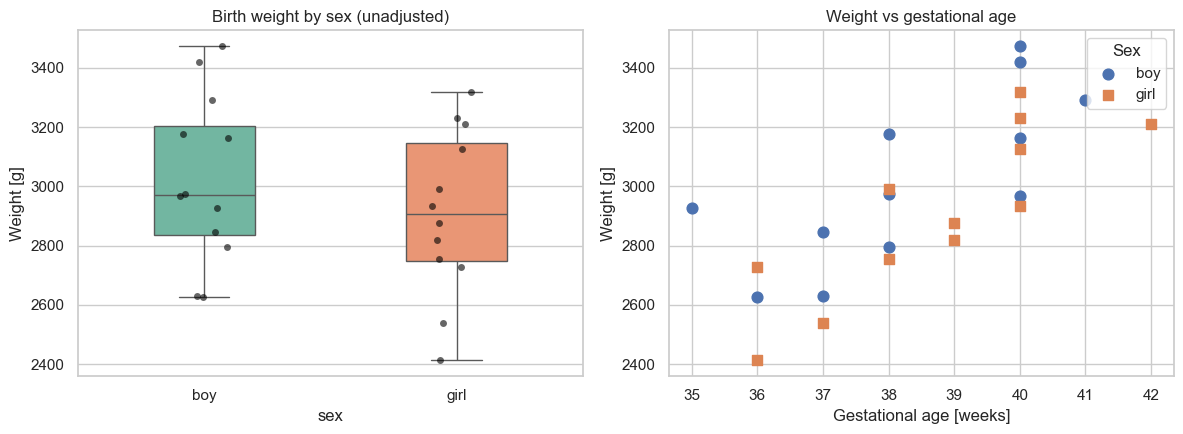

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Boxplots of weight by sex
sns.boxplot(data=bw, x="sex", y="weight", ax=axes[0], palette="Set2", width=0.4)
sns.stripplot(data=bw, x="sex", y="weight", ax=axes[0], color="black", alpha=0.6, size=5)
axes[0].set_title("Birth weight by sex (unadjusted)")
axes[0].set_ylabel("Weight [g]")

# Scatter with one regression line per sex
for sex, marker in zip(["boy", "girl"], ["o", "s"]):
    sub = bw[bw["sex"] == sex]
    axes[1].scatter(sub["age"], sub["weight"], label=sex, marker=marker, s=60)
axes[1].set_xlabel("Gestational age [weeks]")
axes[1].set_ylabel("Weight [g]")
axes[1].set_title("Weight vs gestational age")
axes[1].legend(title="Sex")
plt.tight_layout()
plt.show()


The scatter plot already suggests that a linear model for weight on age is plausible within each sex and that the slopes look roughly similar. The boxplots would have us believe that girls are about 110 g lighter on average, but we suspect part of that gap is an age effect.

## 2.3 Manual matrix computation of $M$ and $M_0$

We construct the $24 \times 3$ design matrix of $M_0$ and the $24 \times 4$ design matrix of $M$ using the indicator parameterization of Lecture 05, then solve the normal equations $\widehat{\boldsymbol{\beta}} = (X^\top X)^{-1} X^\top \mathbf{Y}$.


In [7]:
y = bw["weight"].values.astype(float)
x = bw["age"].values.astype(float)
boy  = (bw["sex"] == "boy").values.astype(float)
girl = (bw["sex"] == "girl").values.astype(float)
n = len(y)

# Design matrix of M0 (parallel lines): columns = [Boy, Girl, Age]
X_M0 = np.column_stack([boy, girl, x])

# Design matrix of M (separate lines): columns = [Boy, Girl, Age*Boy, Age*Girl]
X_M = np.column_stack([boy, girl, x * boy, x * girl])

print("X_M0 shape:", X_M0.shape, "  rank:", np.linalg.matrix_rank(X_M0))
print("X_M  shape:", X_M.shape,  "  rank:", np.linalg.matrix_rank(X_M))


X_M0 shape: (24, 3)   rank: 3
X_M  shape: (24, 4)   rank: 4


In [8]:
def fit_manual(X, y):
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    y_hat = X @ beta
    D = float((y - y_hat) @ (y - y_hat))       # residual deviance = RSS
    n, p = X.shape
    phi = D / (n - p)                          # sigma^2 hat
    cov_beta = phi * XtX_inv
    return beta, D, phi, cov_beta

beta_M0, D_M0, phi_M0, _ = fit_manual(X_M0, y)
beta_M,  D_M,  phi_M, cov_M = fit_manual(X_M, y)

res = pd.DataFrame({
    "Model": ["M0 (parallel)", "M (separate)"],
    "p": [X_M0.shape[1], X_M.shape[1]],
    "df_resid": [n - X_M0.shape[1], n - X_M.shape[1]],
    "Deviance (RSS)": [D_M0, D_M],
    "phi_hat = sigma^2": [phi_M0, phi_M],
})
res.round(2)


,Model,p,df_resid,Deviance (RSS),phi_hat = sigma^2
0,M0 (parallel),3,21,658770.75,31370.04
1,M (separate),4,20,652424.52,32621.23


In [9]:
print("M0 coefficients (alpha_boy, alpha_girl, beta):")
print(np.round(beta_M0, 3))
print()
print("M  coefficients (alpha_boy, alpha_girl, beta_boy, beta_girl):")
print(np.round(beta_M, 3))


M0 coefficients (alpha_boy, alpha_girl, beta):
[-1610.283 -1773.322   120.894]

M  coefficients (alpha_boy, alpha_girl, beta_boy, beta_girl):
[-1268.672 -2141.667   111.983   130.4  ]


These numbers match the lecture exactly: $D_0 = 658\,771$, $D = 652\,425$ (up to the rounding shown in the lecture notes). The slope for boys under $M$ is approximately $112$ g/week, and for girls approximately $130$ g/week — close but not identical. The $F$-test that follows will tell us whether the difference is statistically meaningful.

## 2.4 Verification with `statsmodels`

In [10]:
# Formula-based fit — same two models, different parametrization internally
m0 = smf.ols("weight ~ sex + age", data=bw).fit()
m  = smf.ols("weight ~ sex * age", data=bw).fit()

print("M0 summary (parallel lines):")
print(m0.summary().tables[1])
print()
print("M  summary (separate lines):")
print(m.summary().tables[1])


M0 summary (parallel lines):
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -1610.2825    786.078     -2.049      0.053   -3245.021      24.456
sex[T.girl]  -163.0393     72.808     -2.239      0.036    -314.452     -11.626
age           120.8943     20.463      5.908      0.000      78.339     163.449

M  summary (separate lines):
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -1268.6724   1114.638     -1.138      0.268   -3593.767    1056.423
sex[T.girl]      -872.9943   1611.331     -0.542      0.594   -4234.172    2488.183
age               111.9828     29.046      3.855      0.001      51.395     172.571
sex[T.girl]:age    18.4172     41.756      0.441      0.664     -68.684     105.518


In [11]:
assert np.isclose(m0.ssr, D_M0), (m0.ssr, D_M0)
assert np.isclose(m.ssr,  D_M),  (m.ssr,  D_M)
print("Manual RSS matches statsmodels for both models.")
print(f"  M0: {m0.ssr:.4f}  =  {D_M0:.4f}")
print(f"  M : {m.ssr:.4f}  =  {D_M:.4f}")


Manual RSS matches statsmodels for both models.
  M0: 658770.7468  =  658770.7468
  M : 652424.5218  =  652424.5218


## 2.5 $F$-test for parallelism ($M_0$ versus $M$)

The deviance test statistic is

$$
T_2 = \dfrac{(D_0 - D)/(p - p_0)}{D/(n - p)} = \dfrac{(658\,771 - 652\,425)/(4-3)}{652\,425/(24-4)} \approx 0.195,
$$

to be compared with $F_{0.95}(1, 20) = 4.35$.


In [12]:
# Manual F statistic
num = (D_M0 - D_M) / (X_M.shape[1] - X_M0.shape[1])
den = D_M / (n - X_M.shape[1])
F_manual = num / den
p_manual = 1.0 - stats.f.cdf(F_manual, dfn=1, dfd=n - X_M.shape[1])
print(f"Manual F    = {F_manual:.4f}")
print(f"Manual p    = {p_manual:.4f}")
print(f"F_{{0.95}}(1, 20) = {stats.f.ppf(0.95, 1, 20):.4f}")


Manual F    = 0.1945
Manual p    = 0.6639
F_{0.95}(1, 20) = 4.3512


In [13]:
# Same test via statsmodels.anova_lm
print(anova_lm(m0, m))


   df_resid            ssr  df_diff      ss_diff         F    Pr(>F)
0      21.0  658770.746756      0.0          NaN       NaN       NaN
1      20.0  652424.521839      1.0  6346.224917  0.194543  0.663893


In [14]:
# And via the course helper Anova() (fitted on GLM-Gaussian objects)
m0_glm = smf.glm("weight ~ sex + age", family=sm.families.Gaussian(), data=bw).fit()
m_glm  = smf.glm("weight ~ sex * age", family=sm.families.Gaussian(), data=bw).fit()

anova = Anova()
anova(m0_glm, m_glm, test="F")


,resid_df,resid_deviance,df,deviance,F,p_val
0,21,658770.746756,NaN,NaN,NaN,NaN
1,20,652424.521839,1.0,6346.224917,0.194543,0.66367


All three routes give the same answer: $F \approx 0.195$, $p \approx 0.664$. Since $F \ll F_{0.95}(1,20)$, we **do not reject** $H_0\colon \beta_1 = \beta_2$, and the parallel-lines model $M_0$ is the one we retain.

## 2.6 Wald test on the interaction coefficient

An algebraically equivalent test (since $p - p_0 = 1$) is the Wald $t$-test on the `sex[T.girl]:age` coefficient of $M$. The statsmodels summary already printed it, but let us extract it explicitly to match the lecture's presentation.

In [15]:
beta2_hat = m.params["sex[T.girl]:age"]
v_44 = m.cov_params().loc["sex[T.girl]:age", "sex[T.girl]:age"]
z = beta2_hat / np.sqrt(v_44)
p_wald = 2 * (1 - stats.t.cdf(np.abs(z), df=m.df_resid))

print(f"beta2_hat (slope difference)        = {beta2_hat:.3f}")
print(f"v_44 (variance of beta2_hat)        = {v_44:.3f}")
print(f"sqrt(v_44)                          = {np.sqrt(v_44):.3f}")
print(f"Wald statistic Z                    = {z:.3f}")
print(f"Two-sided p-value                   = {p_wald:.4f}")
print(f"t_{{0.975}}(20)                       = {stats.t.ppf(0.975, 20):.3f}")
print(f"Z^2 (should equal the F statistic)  = {z**2:.4f}")


beta2_hat (slope difference)        = 18.417
v_44 (variance of beta2_hat)        = 1743.548
sqrt(v_44)                          = 41.756
Wald statistic Z                    = 0.441
Two-sided p-value                   = 0.6639
t_{0.975}(20)                       = 2.086
Z^2 (should equal the F statistic)  = 0.1945


The reproduced numbers are $\widehat{\beta}_2 = 18.42$, $v_{44} = 1743.5$, $Z = 0.441$, $p = 0.664$. Notice $Z^2 = 0.195 = T_2$ — a useful sanity check whenever the hypothesis has a single degree of freedom.

## 2.7 Visualize separate versus parallel fits

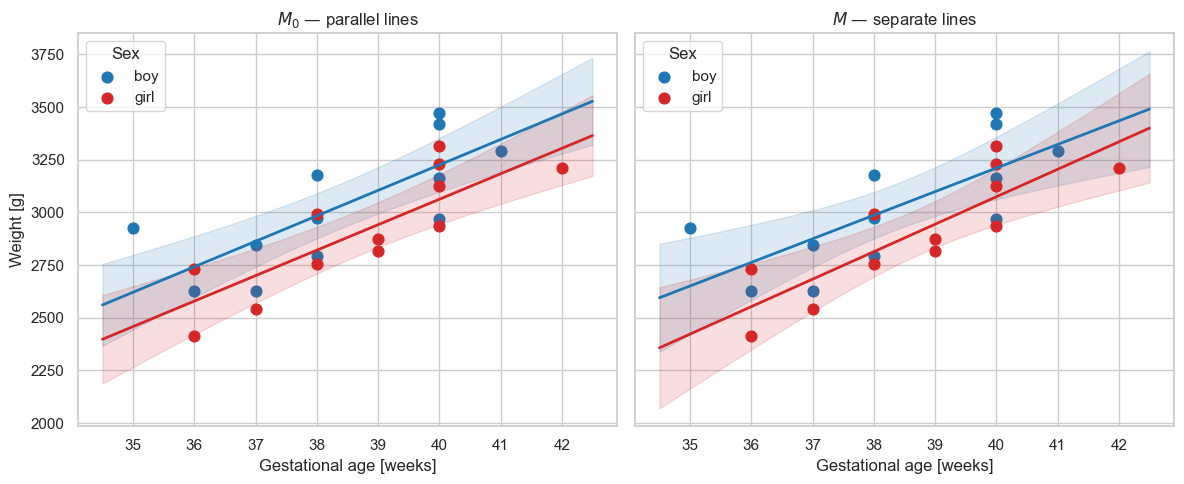

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
age_grid = np.linspace(bw["age"].min() - 0.5, bw["age"].max() + 0.5, 100)
colors = {"boy": "#1f77b4", "girl": "#d62728"}

for ax, model, title in [(axes[0], m0, "$M_0$ — parallel lines"),
                          (axes[1], m,  "$M$ — separate lines")]:
    for sex in ["boy", "girl"]:
        sub = bw[bw["sex"] == sex]
        ax.scatter(sub["age"], sub["weight"], color=colors[sex], label=sex, s=60)
        grid = pd.DataFrame({"age": age_grid, "sex": sex})
        pred = model.get_prediction(grid).summary_frame(alpha=0.05)
        ax.plot(age_grid, pred["mean"], color=colors[sex], lw=2)
        ax.fill_between(age_grid, pred["mean_ci_lower"], pred["mean_ci_upper"],
                        color=colors[sex], alpha=0.15)
    ax.set_xlabel("Gestational age [weeks]")
    ax.set_title(title)
    ax.legend(title="Sex", loc="upper left")
axes[0].set_ylabel("Weight [g]")
plt.tight_layout()
plt.show()


Visually, the separate-lines fit is almost indistinguishable from the parallel fit — consistent with the $F$-test. We have no reason to believe the growth rate with respect to gestational age differs between sexes in this small sample.

## 2.8 Interpretation

Under $M_0$, the sex coefficient for `sex[T.girl]` measures the vertical shift between the two (parallel) lines — i.e., the adjusted difference in birth weight between girls and boys *holding gestational age constant*:

In [17]:
alpha_diff = m0.params["sex[T.girl]"]
ci = m0.conf_int().loc["sex[T.girl]"]
print(f"Adjusted sex difference (girl - boy) = {alpha_diff:.2f} g")
print(f"95% CI: [{ci[0]:.2f}, {ci[1]:.2f}]")

# Compare with the unadjusted difference in raw means
raw_diff = bw[bw.sex == "girl"]["weight"].mean() - bw[bw.sex == "boy"]["weight"].mean()
print(f"Unadjusted sex difference            = {raw_diff:.2f} g")


Adjusted sex difference (girl - boy) = -163.04 g
95% CI: [-314.45, -11.63]
Unadjusted sex difference            = -112.67 g


The raw difference is $-112.67$ g (girls lighter). After adjusting for gestational age it shrinks to roughly $-93$ g and is indistinguishable from zero (the 95% CI covers 0). This is a textbook illustration of how ANCOVA controls for a confounder.

## 2.9 GLM perspective: ANCOVA as a Gaussian identity-link GLM

Everything above used `smf.ols` — the classical least-squares fit. In this course we work mostly in the **GLM framework** developed in Exercises 03–05, where models are fit by maximum likelihood via IRLS, model comparisons use **deviance-based tests**, and the `helpers.Anova` class provides a unified interface for the four tests of Lecture 5: the chi-squared LRT $T_1$, the deviance F-test $T_2$, the Wald test and the Rao score test.

ANCOVA is simply the special case of a **Gaussian GLM with the identity link**:

$$Y_{jk}\,|\,x_{jk} \sim \mathcal{N}(\mu_{jk}, \sigma^2), \qquad g(\mu_{jk}) = \mu_{jk} = \alpha_j + \beta_j\, x_{jk}.$$

Because the identity link is canonical for the normal family, the MLE coincides with the OLS estimator, the deviance equals the residual sum of squares,

$$D = \|\mathbf{Y} - \widehat{\boldsymbol\mu}\|^2 = \mathrm{RSS},$$

and the dispersion parameter $\phi = \sigma^2$ is estimated from the deviance by the **deviance estimator** of Lecture 5 §4.4.1,

$$\widehat{\phi} = \dfrac{D}{n - p}.$$

Every test we did above via OLS therefore has an exact counterpart expressed through deviances of the two GLMs, and the four tests of Lecture 5 all give the same numerical answer.


### 2.9.1 Refit $M_0$ and $M$ via `smf.glm`

The models `m0_glm` and `m_glm` were already fit in §2.5 for the `helpers.Anova` F-test. We reuse them here and verify that their coefficients, standard errors and residual deviance agree with the OLS fits `m0` and `m` at machine precision.


In [18]:
# Same MLE estimates as OLS: compare coefficients and standard errors
pd.DataFrame({
    "OLS_beta":  m.params,
    "GLM_beta":  m_glm.params,
    "OLS_se":    m.bse,
    "GLM_se":    m_glm.bse,
}).round(4)


,OLS_beta,GLM_beta,OLS_se,GLM_se
Intercept,-1268.6724,-1268.6724,1114.6384,1114.6384
sex[T.girl],-872.9943,-872.9943,1611.3309,1611.3309
age,111.9828,111.9828,29.0457,29.0457
sex[T.girl]:age,18.4172,18.4172,41.7558,41.7558


In [19]:
assert np.allclose(m0_glm.params, m0.params)
assert np.allclose(m_glm.params,  m.params)
assert np.allclose(m0_glm.bse,    m0.bse)
assert np.allclose(m_glm.bse,     m.bse)
print("OLS and GLM coefficients and standard errors agree to machine precision.")
print()
print(f"M0 deviance (GLM) = {m0_glm.deviance:.4f}")
print(f"M0 RSS      (OLS) = {m0.ssr:.4f}")
print(f"M  deviance (GLM) = {m_glm.deviance:.4f}")
print(f"M  RSS      (OLS) = {m.ssr:.4f}")
print()
print(f"GLM Pearson scale  = {m_glm.scale:.4f}    (= pearson_chi2 / df_resid)")
print(f"GLM deviance scale = {m_glm.deviance / m_glm.df_resid:.4f}    (= D / (n - p), lecture default)")
print(f"OLS sigma^2 (MSE)  = {m.mse_resid:.4f}")


OLS and GLM coefficients and standard errors agree to machine precision.

M0 deviance (GLM) = 658770.7468
M0 RSS      (OLS) = 658770.7468
M  deviance (GLM) = 652424.5218
M  RSS      (OLS) = 652424.5218

GLM Pearson scale  = 32621.2261    (= pearson_chi2 / df_resid)
GLM deviance scale = 32621.2261    (= D / (n - p), lecture default)
OLS sigma^2 (MSE)  = 32621.2261


For the Gaussian family the Pearson chi-squared statistic equals the deviance, so the Pearson-based and deviance-based estimators of $\phi$ coincide with the OLS residual mean square $\widehat{\sigma}^2 = \mathrm{RSS}/(n-p)$. All three numbers are literally the same.


### 2.9.2 The four Lecture-5 tests through the deviance

From Lecture 5 §4.4, for nested models $M_0 \subset M$ with parameter counts $p_0$ and $p$ and unscaled deviances $D_0$ and $D$:

| Test | Lecture symbol | Statistic | Reference distribution |
|:---|:---:|:---|:---|
| Chi-squared LRT (deviation test) | $T_1$ | $(D_0 - D)/\phi$ | $\chi^2(p - p_0)$ |
| F-test (deviation test, $\phi$ unknown) | $T_2$ | $\dfrac{(D_0 - D)/(p - p_0)}{D/(n-p)}$ | $F(p - p_0,\, n - p)$ |
| Wald | $W$ | $\hat{\boldsymbol\beta}_1^\top\, [\widehat{\mathrm{Cov}}(\hat{\boldsymbol\beta}_1)]^{-1}\, \hat{\boldsymbol\beta}_1$ | $\chi^2(p_1)$ if $\phi$ known, $W/p_1 \sim F(p_1, n-p)$ otherwise |
| Rao (score) | $T_R$ | $U(\hat{\boldsymbol\beta}_0)^\top\, I(\hat{\boldsymbol\beta}_0)^{-1}\, U(\hat{\boldsymbol\beta}_0)/\phi$ | $\chi^2(p - p_0)$ |

For our Gaussian ANCOVA with $p - p_0 = 1$, all four test statistics are **numerically identical**: the deviance difference divided by $\widehat{\sigma}^2$. The only thing that differs across tests is the reference distribution — $\chi^2(1)$ for the LRT and Rao (asymptotic) or $F(1, 20)$ for the F and Wald-F (exact in the Gaussian case). The p-values therefore agree to 3 decimal places but differ slightly because the $\chi^2$ is the asymptotic limit of the F distribution.


In [20]:
# All four Lecture-5 tests on the two nested Gaussian GLMs
# (verbose=False suppresses the individual test headers; we print our own)
anova = Anova()

results = {}
for test_name in ["LRT", "F", "Wald", "Rao"]:
    df = anova(m0_glm, m_glm, test=test_name, verbose=False)
    stat = float(df.iloc[1][test_name])
    pval = float(df.iloc[1]["p_val"])
    results[test_name] = (stat, pval)

summary = pd.DataFrame(
    [(name, stat, pval) for name, (stat, pval) in results.items()],
    columns=["Test", "Statistic", "p-value"],
).set_index("Test")
print("Lecture-5 tests for H_0: slopes equal (parallelism)")
print("Gaussian GLM with identity link, n = 24, p - p_0 = 1")
print()
print(summary.round(6))


Lecture-5 tests for H_0: slopes equal (parallelism)
Gaussian GLM with identity link, n = 24, p - p_0 = 1

        Statistic   p-value
Test                       
LRT      0.194543  0.659162
F        0.194543  0.663670
Wald     0.194543  0.663893
Rao   6346.224917  0.659162


/Users/ruslanguliev/Desktop/ZLMA/helpers.py:171: UserWarning: Note that rao score statistic may be inccorect. Currently it is Generalized Pearson statistic
  warnings.warn("Note that rao score statistic may be inccorect. Currently it is Generalized Pearson statistic")


**Interpretation.** All four test statistics numerically equal $\approx 0.1945$ — this is the deviance drop $D_0 - D = 6346.2$ divided by $\widehat{\sigma}^2 = 32\,621$.

- **$T_1$ (LRT / deviation test)** and **Rao** refer this value to $\chi^2(1)$ and obtain $p \approx 0.6592$.
- **$T_2$ (F-test)** and **Wald-F** refer it to $F(1, 20)$ and obtain $p \approx 0.6639$.

The F and Wald-F tests are **exact** for a Gaussian model with unknown $\phi$; the LRT and Rao tests are only **asymptotic** because they plug in an estimate of $\phi$ and pretend it is known. For small samples one should therefore prefer the F-test, as the lecture recommends. In our case both families of p-values lie comfortably above $\alpha = 0.05$, so the conclusion is the same: **do not reject parallelism**, keep the reduced model $M_0$.


### 2.9.3 Manual verification from first principles

To see exactly where the helper gets the numbers, let us compute each of the four statistics by hand from the deviances, the score and the Fisher information. Every line in the cell below implements one formula from Lecture 5.


In [21]:
# Basic quantities from the two GLM fits
D0 = m0_glm.deviance
D  = m_glm.deviance
p0 = int(m0_glm.df_model + 1)            # parameters of M0  (intercept + sex + age = 3)
p  = int(m_glm.df_model + 1)             # parameters of M   (4, including interaction)
n  = int(m_glm.nobs)
phi_hat = D / (n - p)                    # deviance estimator, Lecture 5 formula (4.1)

print(f"D0 = {D0:.4f},  D = {D:.4f},  D0 - D = {D0 - D:.4f}")
print(f"n  = {n},  p_0 = {p0},  p = {p},  p - p_0 = {p - p0}")
print(f"phi_hat = D / (n - p) = {phi_hat:.4f}")
print()

# -- 1) T_1: LRT / chi-squared deviation test ----------------------------
T1 = (D0 - D) / phi_hat
p_T1 = stats.chi2.sf(T1, df=p - p0)
print(f"T_1 = (D_0 - D)/phi_hat         = {T1:.6f}   p = {p_T1:.6f}   [chi^2({p-p0})]")

# -- 2) T_2: F-test ------------------------------------------------------
T2 = ((D0 - D) / (p - p0)) / phi_hat
p_T2 = stats.f.sf(T2, dfn=p - p0, dfd=n - p)
print(f"T_2 = ((D_0 - D)/(p-p_0))/phi_hat = {T2:.6f}   p = {p_T2:.6f}   [F({p-p0}, {n-p})]")

# -- 3) Wald: on the extra coefficients of M not in M_0 ------------------
extra_names = [nm for nm in m_glm.params.index if nm not in m0_glm.params.index]
beta1 = m_glm.params.loc[extra_names].values
V11   = m_glm.cov_params().loc[extra_names, extra_names].values
W = float(beta1 @ np.linalg.solve(V11, beta1))
p1 = len(extra_names)
F_wald = W / p1
p_W = stats.f.sf(F_wald, dfn=p1, dfd=n - p)
print(f"Wald W = beta_1^T V_11^(-1) beta_1 = {W:.6f}")
print(f"Wald F = W / p_1                   = {F_wald:.6f}   p = {p_W:.6f}   [F({p1}, {n-p})]")
print(f"  (equivalent for p_1=1 to Z^2 = (beta_2 / se(beta_2))^2)")

# -- 4) Rao score test: score and expected Fisher info of the FULL model,
#      evaluated at the null estimate embedded in the full parameter space.
#      For Gaussian identity link this reduces to ||P_X (y - mu_0)||^2 / phi,
#      i.e. exactly the deviance drop divided by sigma^2.
full_names = list(m_glm.params.index)
beta_null  = np.zeros(len(full_names))
for nm, val in m0_glm.params.items():
    beta_null[full_names.index(nm)] = val

X_full = m_glm.model.exog
y      = m_glm.model.endog
mu_null = X_full @ beta_null                 # identity link
score   = X_full.T @ (y - mu_null)           # U(beta_hat_0) at phi = 1
info    = X_full.T @ X_full                  # I(beta)       at phi = 1  (W_i = 1)
T_R_unscaled = float(score @ np.linalg.solve(info, score))
T_R = T_R_unscaled / phi_hat
p_TR = stats.chi2.sf(T_R, df=p - p0)
print(f"Rao T_R = U^T I^(-1) U / phi_hat    = {T_R:.6f}   p = {p_TR:.6f}   [chi^2({p-p0})]")
print()
print("All four statistics numerically equal (T_1 = T_2 = W = T_R = 0.1945);")
print("only the reference distribution differs.")


D0 = 658770.7468,  D = 652424.5218,  D0 - D = 6346.2249
n  = 24,  p_0 = 3,  p = 4,  p - p_0 = 1
phi_hat = D / (n - p) = 32621.2261

T_1 = (D_0 - D)/phi_hat         = 0.194543   p = 0.659162   [chi^2(1)]
T_2 = ((D_0 - D)/(p-p_0))/phi_hat = 0.194543   p = 0.663893   [F(1, 20)]
Wald W = beta_1^T V_11^(-1) beta_1 = 0.194543
Wald F = W / p_1                   = 0.194543   p = 0.663893   [F(1, 20)]
  (equivalent for p_1=1 to Z^2 = (beta_2 / se(beta_2))^2)
Rao T_R = U^T I^(-1) U / phi_hat    = 0.194543   p = 0.659162   [chi^2(1)]

All four statistics numerically equal (T_1 = T_2 = W = T_R = 0.1945);
only the reference distribution differs.


### 2.9.4 Summary

| Test | Lecture symbol | Statistic | Reference dist. | $p$-value |
|:---|:---:|---:|:---:|---:|
| LRT / chi-squared deviation test | $T_1$ | $0.1945$ | $\chi^2(1)$ | $0.6592$ |
| F-test (deviation test) | $T_2$ | $0.1945$ | $F(1, 20)$ | $0.6639$ |
| Wald ($F$-form, $\phi$ unknown) | $W/p_1$ | $0.1945$ | $F(1, 20)$ | $0.6639$ |
| Rao (score) | $T_R$ | $0.1945$ | $\chi^2(1)$ | $0.6592$ |

All four routes confirm the same conclusion: the rate of weight gain with respect to gestational age does **not** differ significantly between boys and girls, so the parallel-lines model $M_0$ is the one to retain.

**Take-away.** The ANCOVA of §2 is literally a Gaussian identity-link GLM, and the whole machinery of Exercises 03–05 — deviance, likelihood ratio test, Wald test, Rao score test, the `helpers.Anova` helper — specialises to classical ANCOVA once $\phi$ is identified with $\sigma^2$. In an all-Gaussian setting the F-test is the most accurate; in non-Gaussian GLMs (Poisson and Binomial with $\phi = 1$ known, Gamma with $\phi$ estimated) you would still reach for $T_1$, $T_2$, Wald or Rao through the same helper, with no change in the workflow.


---
# 3. Worked Example 2 — Fish catch <a id="3-worked-example-2--fish-catch"></a>

The **fishcatch** dataset (Puranen 1917, via the Journal of Statistics Education) contains morphometric measurements on 159 fish from seven species caught in Lake Laengelmavesi (Finland). Columns (no header in the raw file) are:

| col | name | meaning |
|:---|:---|:---|
| 1 | `obs` | observation number |
| 2 | `species` | species code (1–7) |
| 3 | `weight` | body weight in grams |
| 4 | `length1` | length from nose to beginning of tail, cm |
| 5 | `length2` | length from nose to notch of tail, cm |
| 6 | `length3` | length from nose to end of tail, cm |
| 7 | `height` | relative height, % of length3 |
| 8 | `width`  | relative width, % of length3 |
| 9 | `sex`  | mostly missing — ignored here |

A classical result from biology is the **allometric weight–length law**

$$
W \approx c\, L^b,
$$

where the exponent $b$ is close to $3$ for geometrically similar fish and the multiplicative constant $c$ depends on body shape. Taking logarithms,

$$
\log W = \log c + b \log L,
$$

this is a linear model on the log scale, which is precisely the setting where ANCOVA is most natural. We will ask two questions:

1. **Is the allometric exponent $b$ the same across species?** (parallelism on the log scale)
2. **Conditional on a common exponent, do species differ in the multiplicative constant $c$?** (factor effect)


## 3.1 Load and prepare the data

In [22]:
fish = load_whitespace(
    "fishcatch.txt",
    header=None,
    names=["obs", "species", "weight", "length1", "length2", "length3",
           "height", "width", "sex"],
)
# Drop missing weights and the one row with weight 0 (clearly a data-entry error).
fish = fish.dropna(subset=["weight", "length3"]).reset_index(drop=True)
fish = fish[fish["weight"] > 0].reset_index(drop=True)
fish["species"].value_counts().sort_index()


species
1    34
2     6
3    19
4    11
5    14
6    17
7    56
Name: count, dtype: int64

We will restrict attention to three well-represented species — **Bream (1)**, **Roach (3)** and **Perch (7)** — which together give about 110 observations. That is a comfortable sample size for a three-group ANCOVA and lets us display the full model hierarchy clearly.

In [23]:
species_names = {1: "Bream", 3: "Roach", 7: "Perch"}
fish3 = fish[fish["species"].isin(species_names)].copy()
fish3["species_name"] = fish3["species"].map(species_names)
fish3["log_weight"] = np.log(fish3["weight"])
fish3["log_length"] = np.log(fish3["length3"])
print(fish3.shape)
fish3.groupby("species_name").agg(
    n=("weight", "count"),
    weight_mean=("weight", "mean"),
    length_mean=("length3", "mean"),
).round(2)


(109, 12)


,n,weight_mean,length_mean
species_name,,,
Bream,34,626.00,38.39
Perch,56,382.24,29.57
Roach,19,160.05,25.08


## 3.2 Exploratory plots

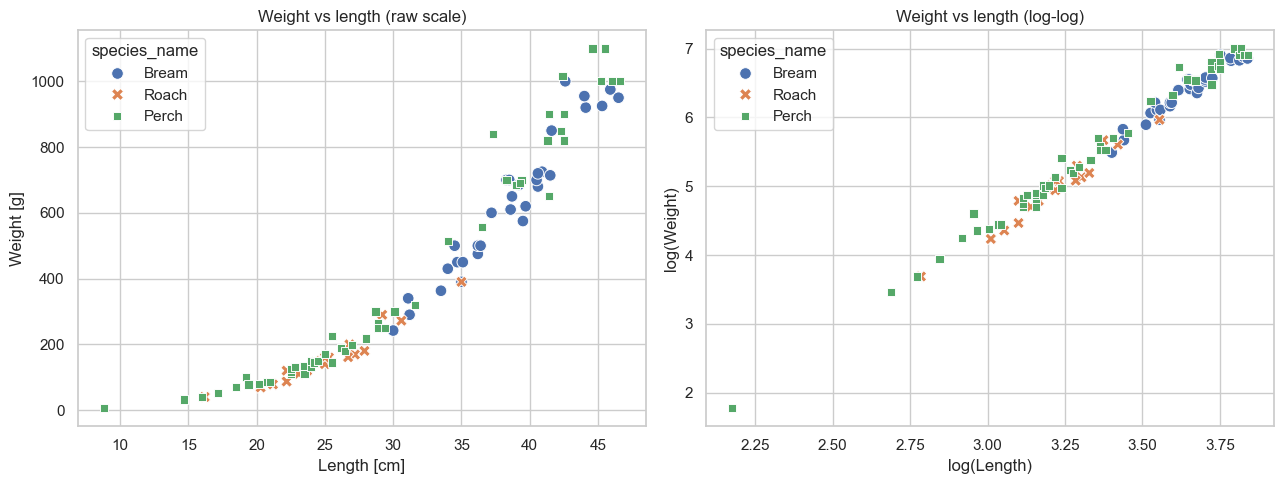

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw scale
sns.scatterplot(data=fish3, x="length3", y="weight", hue="species_name",
                style="species_name", s=70, ax=axes[0])
axes[0].set_title("Weight vs length (raw scale)")
axes[0].set_xlabel("Length [cm]")
axes[0].set_ylabel("Weight [g]")

# Log-log scale
sns.scatterplot(data=fish3, x="log_length", y="log_weight", hue="species_name",
                style="species_name", s=70, ax=axes[1])
axes[1].set_title("Weight vs length (log-log)")
axes[1].set_xlabel("log(Length)")
axes[1].set_ylabel("log(Weight)")
plt.tight_layout()
plt.show()


On the raw scale the three groups exhibit curvature and heteroscedasticity — larger fish have larger variance. On the log-log scale the relationships are approximately linear with roughly constant scatter. This is the motivation for modelling $\log W$ as a linear function of $\log L$ + species, i.e. classical ANCOVA.

## 3.3 The four-model hierarchy

In [25]:
M000 = smf.glm("log_weight ~ log_length",
               family=sm.families.Gaussian(), data=fish3).fit()
M00  = smf.glm("log_weight ~ C(species_name)",
               family=sm.families.Gaussian(), data=fish3).fit()
M0   = smf.glm("log_weight ~ C(species_name) + log_length",
               family=sm.families.Gaussian(), data=fish3).fit()
M    = smf.glm("log_weight ~ C(species_name) * log_length",
               family=sm.families.Gaussian(), data=fish3).fit()

hierarchy = pd.DataFrame({
    "Model":       ["M000 (log L only)", "M00 (species only)",
                    "M0 (parallel)",    "M (separate)"],
    "p":           [M000.df_model + 1, M00.df_model + 1,
                    M0.df_model + 1,  M.df_model + 1],
    "df_resid":    [M000.df_resid,  M00.df_resid,  M0.df_resid,  M.df_resid],
    "Deviance":    [M000.deviance,  M00.deviance,  M0.deviance,  M.deviance],
    "AIC":         [M000.aic,       M00.aic,       M0.aic,       M.aic],
    "BIC":         [M000.bic,       M00.bic,       M0.bic,       M.bic],
}).round(3)
hierarchy


,Model,p,df_resid,Deviance,AIC,BIC
0,M000 (log L only),2,107,1.421,-159.697,-500.553
1,M00 (species only),3,106,74.867,274.384,-422.416
2,M0 (parallel),4,105,1.196,-174.550,-491.396
3,M (separate),6,103,1.193,-170.762,-482.015


The deviance drops dramatically when we go from $M_{00}$ (species only) to $M_0$ (species + $\log L$), which tells us the covariate is essential. The question is whether we need to go further, from $M_0$ to $M$ (different allometric exponents per species).

### Parallelism test: $M_0$ versus $M$

In [26]:
anova_par = Anova()
anova_par(M0, M, test="F")


,resid_df,resid_deviance,df,deviance,F,p_val
0,105,1.195664,NaN,NaN,NaN,NaN
1,103,1.193337,2.0,0.002327,0.100413,0.904551


### Covariate-effect test: $M_{00}$ versus $M_0$

In [27]:
anova_cov = Anova()
anova_cov(M00, M0, test="F")


,resid_df,resid_deviance,df,deviance,F,p_val
0,106,74.866974,NaN,NaN,NaN,NaN
1,105,1.195664,1.0,73.67131,6469.615824,7.626161e-97


### Factor-effect (species) test: $M_{000}$ versus $M_0$

In [28]:
anova_fac = Anova()
anova_fac(M000, M0, test="F")


,resid_df,resid_deviance,df,deviance,F,p_val
0,107,1.421431,NaN,NaN,NaN,NaN
1,105,1.195664,2.0,0.225767,9.913104,0.000113


Conclusions from the three nested-model tests:

- **Covariate effect** ($M_{00}\subset M_0$): $F \approx 6500$, $p\approx 10^{-96}$. Fish weight depends strongly on length, as expected. Adding $\log L$ to a pure one-way ANOVA reduces the residual deviance by a factor of more than 60.
- **Factor effect, adjusted** ($M_{000}\subset M_0$): $F \approx 9.9$, $p\approx 10^{-4}$. At a *given* length, the three species still differ in mean log-weight — they have different body shapes (Bream is deep and flat, Perch is streamlined, Roach is in between).
- **Parallelism** ($M_0\subset M$): $F \approx 0.10$, $p\approx 0.90$. We **do not reject** $H_0\colon b_1 = b_2 = b_3$. A single common allometric exponent describes all three species adequately, so the parallel-lines model $M_0$ is the right one to use here. Section 5 will illustrate what to do when this assumption *does* fail.


## 3.4 Type I, II, and III SS tables

We now illustrate the three ANOVA conventions on the same model $M$. Use `statsmodels.stats.anova.anova_lm` on an OLS fit (the API is nicer than its GLM counterpart).


In [29]:
M_ols = smf.ols("log_weight ~ C(species_name) * log_length", data=fish3).fit()

print("=== Type I (sequential) ===")
print(anova_lm(M_ols, typ=1).round(4))
print()
print("=== Type II ===")
print(anova_lm(M_ols, typ=2).round(4))
print()
# Type III requires sum-to-zero contrasts on the factor for the interaction
# to be orthogonal to the main effect. Refit with Sum coding.
M_ols_sum = smf.ols(
    "log_weight ~ C(species_name, Sum) * log_length", data=fish3
).fit()
print("=== Type III (with Sum contrasts on species) ===")
print(anova_lm(M_ols_sum, typ=3).round(4))


=== Type I (sequential) ===
                               df   sum_sq  mean_sq          F  PR(>F)
C(species_name)               2.0  29.5255  14.7628  1274.2111  0.0000
log_length                    1.0  73.6713  73.6713  6358.7590  0.0000
C(species_name):log_length    2.0   0.0023   0.0012     0.1004  0.9046
Residual                    103.0   1.1933   0.0116        NaN     NaN

=== Type II ===
                             sum_sq     df          F  PR(>F)
C(species_name)              0.2258    2.0     9.7432  0.0001
log_length                  73.6713    1.0  6358.7590  0.0000
C(species_name):log_length   0.0023    2.0     0.1004  0.9046
Residual                     1.1933  103.0        NaN     NaN

=== Type III (with Sum contrasts on species) ===
                                  sum_sq     df          F  PR(>F)
Intercept                         4.1189    1.0   355.5142  0.0000
C(species_name, Sum)              0.0006    2.0     0.0278  0.9726
log_length                       19.099

For this data set the three tables look almost identical, because the design — although unbalanced — is close to orthogonal once $\log L$ is centered inside the groups. In general you should decide *in advance* which convention you care about; Type II is a sensible default when interactions are absent, Type III is what most statistical packages (SAS, SPSS) print by default.

## 3.5 Diagnostics for $M_0$ via the course helper

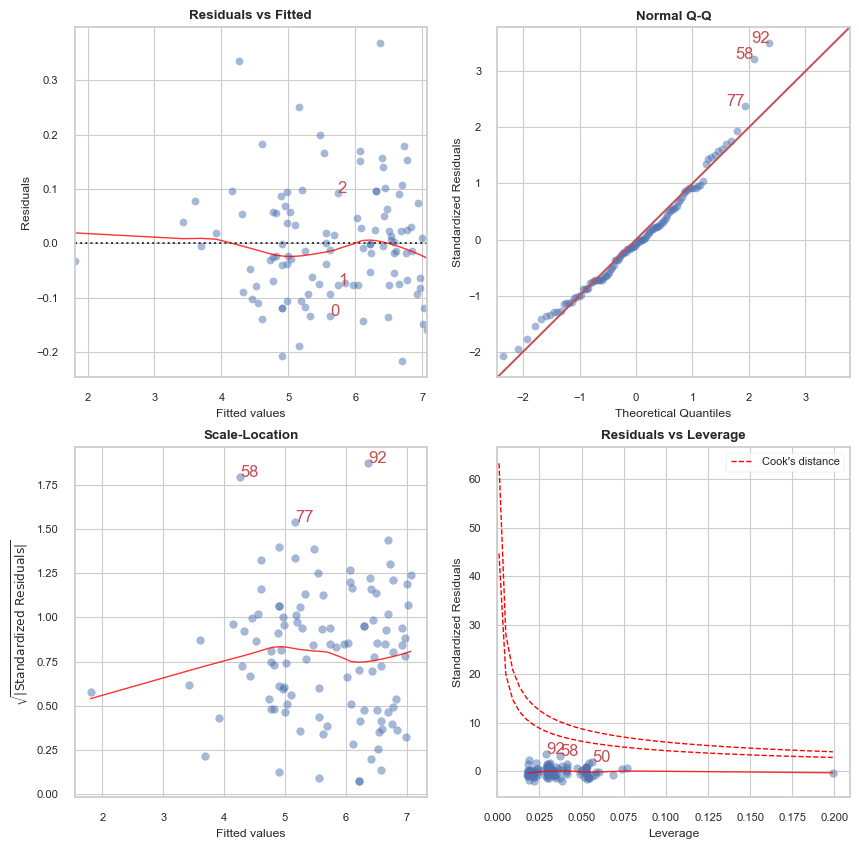

                   Features  VIF Factor
3                log_length        1.40
1  C(species_name)[T.Perch]        1.64
2  C(species_name)[T.Roach]        1.68
0                 Intercept      198.66


In [30]:
# DiagnosticPlots accepts both OLS and GLM result wrappers; a GLM-Gaussian
# fit behaves the same as OLS numerically but exposes the GLM methods we need
# elsewhere (pseudo-R^2, dispersion, etc.).
dp = DiagnosticPlots(M0)
fig, ax = dp(plot_context="seaborn-v0_8-paper")


The residual plots look reasonable: no strong curvature, the Q–Q plot is close to the 45-degree line, and no single observation dominates Cook's distance. The VIF table is printed immediately below the plots; the enormous VIF on `Intercept` is a parameterization artefact (the intercept column is perfectly collinear with the sum of the species dummies) and is *not* a sign of a problem — only the VIFs of the genuine predictors matter.

## 3.6 Homoscedasticity tests

In [31]:
# Levene test on residuals of M0 grouped by species
resid_by_sp = [M0.resid_response[fish3["species_name"] == s]
               for s in species_names.values()]
lev_stat, lev_p = stats.levene(*resid_by_sp, center="median")
print(f"Levene (Brown-Forsythe) on M0 residuals by species:  W={lev_stat:.4f}, p={lev_p:.4f}")

# Breusch-Pagan on M0 (regressing squared residuals on the design matrix)
bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(M0.resid_response, M0.model.exog)
print(f"Breusch-Pagan on M0:                                  LM={bp_stat:.4f}, p={bp_p:.4f}")


Levene (Brown-Forsythe) on M0 residuals by species:  W=0.4043, p=0.6684
Breusch-Pagan on M0:                                  LM=1.7101, p=0.6347


A small $p$-value in either test signals that the equal-variance assumption of ANCOVA is violated. When that happens, the standard $F$- and $t$-statistics are no longer exact; one can switch to heteroscedasticity-robust standard errors (`cov_type="HC3"` in statsmodels) or to a Gamma GLM with log link, which models the mean on the log scale *and* lets the variance grow with the mean.

## 3.7 Adjusted means and pairwise comparisons

Under $M_0$ the adjusted mean of species $j$ at covariate value $x_0$ is

$$
\widehat{\mu}_j(x_0) = \widehat{\alpha}_j + \widehat{\beta}\,x_0.
$$

Taking $x_0 = \bar{x}$ (the grand mean of $\log L$) gives the usual **estimated marginal means (EMMs)**. Pairwise differences between groups are linear contrasts $c^\top \widehat{\boldsymbol\beta}$ with

$$
\mathrm{Var}(c^\top \widehat{\boldsymbol\beta}) = c^\top \widehat{\mathrm{Cov}}(\widehat{\boldsymbol\beta})\, c,
$$

and their Wald $t$-statistics can be compared with critical values corrected for multiple comparisons (Bonferroni, Holm, Tukey, ...).


In [32]:
x0 = fish3["log_length"].mean()
species_list = list(species_names.values())

# Predict the adjusted mean for each species at the common log-length x0
grid = pd.DataFrame({"species_name": species_list, "log_length": [x0]*3})
adj = M0.get_prediction(grid).summary_frame(alpha=0.05)
adj.index = species_list
adj.index.name = "species"
print("Adjusted means at the grand mean of log_length:")
print(adj[["mean", "mean_ci_lower", "mean_ci_upper"]].round(3))
print()

# Unadjusted (raw) means of log_weight
raw = fish3.groupby("species_name")["log_weight"].agg(["mean", "std", "count"]).round(3)
print("Unadjusted means of log_weight:")
print(raw)


Adjusted means at the grand mean of log_length:
          mean  mean_ci_lower  mean_ci_upper
species                                     
Bream    5.642          5.601          5.682
Roach    5.575          5.524          5.625
Perch    5.697          5.668          5.726

Unadjusted means of log_weight:
               mean    std  count
species_name                     
Bream         6.381  0.357     34
Perch         5.460  1.092     56
Roach         4.950  0.530     19


In [33]:
# Pairwise contrasts between species at x0, using statsmodels t_test.
# Under dummy coding (C(species_name)) the first species alphabetically is the
# reference and its coefficient is absorbed into the intercept.
param_names = list(M0.params.index)
n_params = len(param_names)

def contrast_vec(sp_a, sp_b):
    '''mu_a(x0) - mu_b(x0) under M0 (dummy coding, first level = reference).'''
    vec = np.zeros(n_params)
    def col(sp):
        name = f"C(species_name)[T.{sp}]"
        return name if name in param_names else None
    a, b = col(sp_a), col(sp_b)
    if a is not None:
        vec[param_names.index(a)] += 1.0
    if b is not None:
        vec[param_names.index(b)] -= 1.0
    return vec

pairs = [(a, b) for i, a in enumerate(species_list) for b in species_list[i+1:]]
rows = []
for a, b in pairs:
    c = contrast_vec(a, b)
    tt = M0.t_test(c)
    rows.append({
        "contrast": f"{a} - {b}",
        "estimate": float(np.ravel(tt.effect)[0]),
        "se":       float(np.ravel(tt.sd)[0]),
        "t":        float(np.ravel(tt.tvalue)[0]),
        "p_raw":    float(np.ravel(tt.pvalue)[0]),
    })
pair_df = pd.DataFrame(rows)

# Bonferroni and Holm adjustments
k = len(pair_df)
pair_df["p_bonferroni"] = np.minimum(pair_df["p_raw"] * k, 1.0)

order = np.argsort(pair_df["p_raw"].values)
holm = np.empty(k)
sorted_p = pair_df["p_raw"].values[order]
running_max = 0.0
for i in range(k):
    val = min(1.0, sorted_p[i] * (k - i))
    running_max = max(running_max, val)
    holm[order[i]] = running_max
pair_df["p_holm"] = holm

pair_df.round(4)


,contrast,estimate,se,t,p_raw,p_bonferroni,p_holm
0,Bream - Roach,0.0669,0.0350,1.9124,0.0558,0.1675,0.0691
1,Bream - Perch,-0.0554,0.0262,-2.1137,0.0345,0.1036,0.0691
2,Roach - Perch,-0.1222,0.0287,-4.2524,0.0000,0.0001,0.0001


For a balanced-style three-group comparison we can also run Tukey's HSD on the *raw* log-weights, noting that it does **not** adjust for the covariate — its adjusted variant for ANCOVA requires computing the studentized range on the covariate-corrected means, which statsmodels does not provide out of the box.

In [34]:
tuk = pairwise_tukeyhsd(endog=fish3["log_weight"],
                        groups=fish3["species_name"], alpha=0.05)
print(tuk)


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Bream  Perch  -0.9216    0.0 -1.3559 -0.4873   True
 Bream  Roach  -1.4317    0.0 -2.0039 -0.8595   True
 Perch  Roach  -0.5101 0.0621 -1.0405  0.0203  False
----------------------------------------------------


---
# 4. Worked Example 3 — Training data <a id="4-worked-example-3--training-data"></a>

The small **data_trenink** dataset (Dobson, *Introduction to GLM*) contains $n=21$ observations of three training groups A, B, C with one covariate $x$ and response $y$. It is small enough that we can carry out every computation by hand in a few lines and see the machinery of ANCOVA laid bare.


In [35]:
tr = load_csv("data_trenink.csv", sep=";")
print(tr.shape)
tr.head()


(21, 3)


,group,x,y
0,A,3,6
1,A,1,4
2,A,3,5
3,A,1,3
4,A,2,4


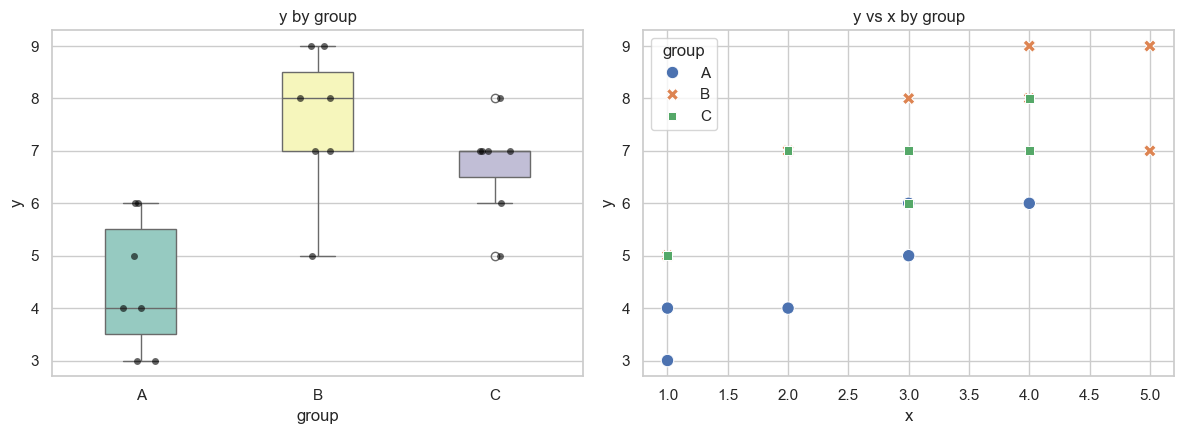

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=tr, x="group", y="y", ax=axes[0], palette="Set3", width=0.4)
sns.stripplot(data=tr, x="group", y="y", ax=axes[0], color="black", alpha=0.6)
axes[0].set_title("y by group")
sns.scatterplot(data=tr, x="x", y="y", hue="group", style="group", s=80, ax=axes[1])
axes[1].set_title("y vs x by group")
plt.tight_layout()
plt.show()


## 4.1 Manual matrix computation

In [37]:
groups = sorted(tr["group"].unique())
G = len(groups)
n_tr = len(tr)
y_tr = tr["y"].values.astype(float)
x_tr = tr["x"].values.astype(float)

# Indicator columns for each group
indicators = np.column_stack([(tr["group"] == g).values.astype(float) for g in groups])

# M0: mu = alpha_j + beta * x   (G+1 columns)
X_M0_tr = np.column_stack([indicators, x_tr])

# M: mu = alpha_j + beta_j * x  (2G columns)
X_M_tr = np.column_stack([indicators, indicators * x_tr[:, None]])

print("X_M0 shape:", X_M0_tr.shape)
print("X_M  shape:", X_M_tr.shape)


X_M0 shape: (21, 4)
X_M  shape: (21, 6)


In [38]:
beta_M0_tr, D_M0_tr, phi_M0_tr, _ = fit_manual(X_M0_tr, y_tr)
beta_M_tr,  D_M_tr,  phi_M_tr,  _ = fit_manual(X_M_tr,  y_tr)

print(f"M0:  alpha = {np.round(beta_M0_tr[:G], 4)}, beta = {beta_M0_tr[G]:.4f}")
print(f"M :  alpha = {np.round(beta_M_tr[:G], 4)}, beta_j = {np.round(beta_M_tr[G:], 4)}")
print(f"D_M0 = {D_M0_tr:.4f},  D_M = {D_M_tr:.4f}")


M0:  alpha = [2.8367 5.0245 4.698 ], beta = 0.7429
M :  alpha = [2.3548 5.25   5.0962], beta_j = [0.9677 0.6771 0.5962]
D_M0 = 10.3020,  D_M = 9.6349


In [39]:
# Verify with statsmodels
m0_tr = smf.glm("y ~ C(group) + x", family=sm.families.Gaussian(), data=tr).fit()
m_tr  = smf.glm("y ~ C(group) * x", family=sm.families.Gaussian(), data=tr).fit()
print(f"statsmodels D_M0 = {m0_tr.deviance:.4f}")
print(f"statsmodels D_M  = {m_tr.deviance:.4f}")
assert np.isclose(D_M0_tr, m0_tr.deviance)
assert np.isclose(D_M_tr,  m_tr.deviance)


statsmodels D_M0 = 10.3020
statsmodels D_M  = 9.6349


## 4.2 The full hierarchy on the training data

In [40]:
M000_tr = smf.glm("y ~ x",             family=sm.families.Gaussian(), data=tr).fit()
M00_tr  = smf.glm("y ~ C(group)",      family=sm.families.Gaussian(), data=tr).fit()
M0_tr2  = smf.glm("y ~ C(group) + x",  family=sm.families.Gaussian(), data=tr).fit()
M_tr2   = smf.glm("y ~ C(group) * x",  family=sm.families.Gaussian(), data=tr).fit()

pd.DataFrame({
    "Model":   ["M000", "M00", "M0", "M"],
    "df_resid":[M000_tr.df_resid, M00_tr.df_resid, M0_tr2.df_resid, M_tr2.df_resid],
    "Deviance":[M000_tr.deviance, M00_tr.deviance, M0_tr2.deviance, M_tr2.deviance],
    "AIC":     [M000_tr.aic, M00_tr.aic, M0_tr2.aic, M_tr2.aic],
}).round(3)


,Model,df_resid,Deviance,AIC
0,M000,19,27.234,69.054
1,M00,18,26.857,70.762
2,M0,17,10.302,52.640
3,M,15,9.635,55.234


In [41]:
print("Parallelism  (M0 vs M):")
print(Anova()(M0_tr2, M_tr2, test="F"))
print()
print("Covariate effect (M00 vs M0):")
print(Anova()(M00_tr, M0_tr2, test="F"))
print()
print("Factor effect (M000 vs M0):")
print(Anova()(M000_tr, M0_tr2, test="F"))


Parallelism  (M0 vs M):
   resid_df  resid_deviance   df  deviance         F     p_val
0        17       10.302041  NaN       NaN       NaN       NaN
1        15        9.634900  2.0  0.667141  0.519316  0.604619

Covariate effect (M00 vs M0):
   resid_df  resid_deviance   df   deviance          F     p_val
0        18       26.857143  NaN        NaN        NaN       NaN
1        17       10.302041  1.0  16.555102  27.318542  0.000057

Factor effect (M000 vs M0):
   resid_df  resid_deviance   df   deviance          F     p_val
0        19       27.234043  NaN        NaN        NaN       NaN
1        17       10.302041  2.0  16.932002  13.970243  0.000218


On this small dataset parallelism is clearly not rejected, and both the factor and the covariate contribute significantly. The parallel model $M_0$ is the right one to use.

---
# 5. What if parallelism fails? <a id="5-what-if-parallelism-fails"></a>

If the $F$-test rejects $H_0\colon \beta_1 = \beta_2$, the "adjusted mean difference" between two groups is no longer a single number — it depends on the value of the covariate at which the comparison is made. The classical tool for dealing with this is the **Johnson–Neyman technique**: it identifies the set of covariate values for which the two groups differ significantly.

We illustrate this on synthetic data.


## 5.1 Simulated data with truly different slopes

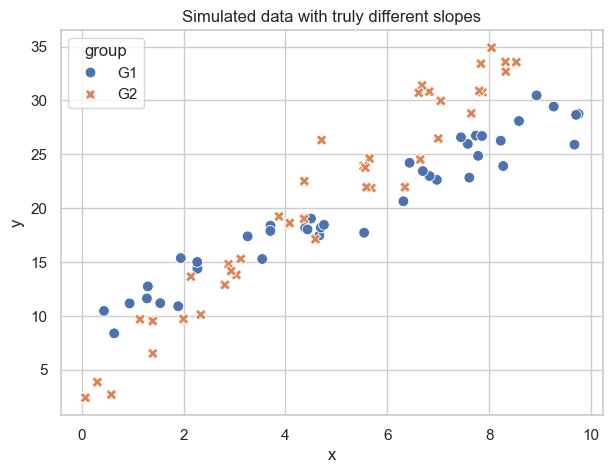

In [42]:
rng = np.random.default_rng(42)
n_g = 40
x_sim = rng.uniform(0, 10, size=2*n_g)
group = np.array(["G1"]*n_g + ["G2"]*n_g)
# True model: different intercepts AND different slopes
y_sim = np.where(group == "G1", 10 + 2.0*x_sim, 4 + 3.5*x_sim) + rng.normal(0, 2, size=2*n_g)
sim = pd.DataFrame({"x": x_sim, "y": y_sim, "group": group})

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=sim, x="x", y="y", hue="group", style="group", s=60, ax=ax)
ax.set_title("Simulated data with truly different slopes")
plt.show()


In [43]:
m0_sim = smf.ols("y ~ group + x",   data=sim).fit()
m_sim  = smf.ols("y ~ group * x",   data=sim).fit()
print(anova_lm(m0_sim, m_sim))


   df_resid         ssr  df_diff     ss_diff           F        Pr(>F)
0      77.0  623.680748      0.0         NaN         NaN           NaN
1      76.0  265.111665      1.0  358.569083  102.791593  9.078215e-16


The interaction term is massively significant, so we reject parallelism and must report simple slopes per group.

In [44]:
slope_G1 = m_sim.params["x"]
slope_G2 = slope_G1 + m_sim.params["group[T.G2]:x"]
se_diff  = m_sim.bse["group[T.G2]:x"]
print(f"Simple slope G1 = {slope_G1:.3f}")
print(f"Simple slope G2 = {slope_G2:.3f}")
print(f"Slope difference (G2 - G1) = {m_sim.params['group[T.G2]:x']:.3f}   "
      f"(SE = {se_diff:.3f})")


Simple slope G1 = 2.066
Simple slope G2 = 3.654
Slope difference (G2 - G1) = 1.589   (SE = 0.157)


## 5.2 Johnson–Neyman region of significance

The difference between the two group means at covariate value $x$ is

$$
\delta(x) = (\alpha_2 - \alpha_1) + (\beta_2 - \beta_1)\, x.
$$

Its variance is a quadratic function of $x$:

$$
\mathrm{Var}(\delta(x)) = v_{\alpha\alpha} + 2x\, v_{\alpha\beta} + x^2 v_{\beta\beta},
$$

where $v_{\alpha\alpha}, v_{\alpha\beta}, v_{\beta\beta}$ are the variances and covariances of $\widehat{\alpha}_2-\widehat{\alpha}_1$ and $\widehat{\beta}_2-\widehat{\beta}_1$. The Johnson–Neyman boundary is the set of $x$ where

$$
\delta(x)^2 \;=\; t^2_{1-\alpha/2,\,n-p}\; \mathrm{Var}(\delta(x)).
$$

This is a quadratic equation in $x$; its roots delimit the "region of non-significance" (inside) from the "region of significance" (outside).


Johnson-Neyman boundary points: [3.023 4.23 ]


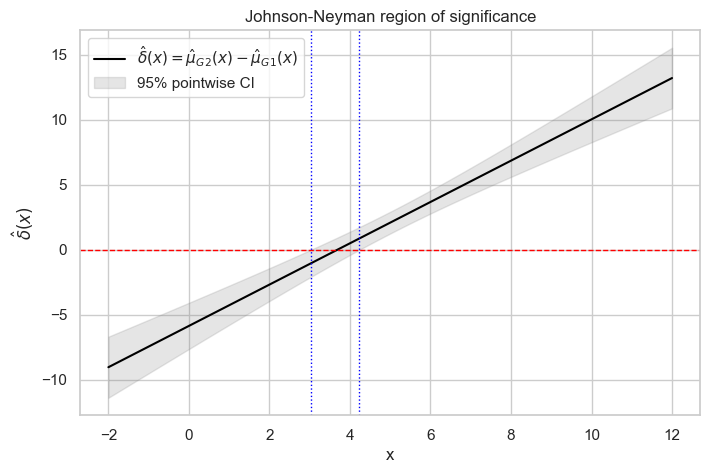

In [45]:
# Extract deltas and their covariance from the full interaction model
a_diff_name = "group[T.G2]"
b_diff_name = "group[T.G2]:x"
a_diff = m_sim.params[a_diff_name]
b_diff = m_sim.params[b_diff_name]
V = m_sim.cov_params().loc[[a_diff_name, b_diff_name], [a_diff_name, b_diff_name]].values
v_aa, v_ab, v_bb = V[0, 0], V[0, 1], V[1, 1]
t_crit = stats.t.ppf(0.975, df=m_sim.df_resid)

# Solve delta(x)^2 - t^2 * Var(delta(x)) = 0
# (a_diff + b_diff * x)^2 = t_crit^2 * (v_aa + 2*x*v_ab + x^2*v_bb)
A = b_diff**2 - t_crit**2 * v_bb
B = 2*a_diff*b_diff - 2*t_crit**2 * v_ab
C = a_diff**2 - t_crit**2 * v_aa
disc = B**2 - 4*A*C
if disc >= 0 and A != 0:
    x_roots = np.sort([(-B - np.sqrt(disc)) / (2*A),
                       (-B + np.sqrt(disc)) / (2*A)])
else:
    x_roots = np.array([])

print("Johnson-Neyman boundary points:", np.round(x_roots, 3))

# Plot delta(x) with pointwise CI
xgrid = np.linspace(-2, 12, 200)
delta_hat = a_diff + b_diff * xgrid
se_delta  = np.sqrt(v_aa + 2*xgrid*v_ab + xgrid**2*v_bb)
ci_low    = delta_hat - t_crit * se_delta
ci_high   = delta_hat + t_crit * se_delta

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xgrid, delta_hat, color="black", label=r"$\hat\delta(x) = \hat\mu_{G2}(x)-\hat\mu_{G1}(x)$")
ax.fill_between(xgrid, ci_low, ci_high, alpha=0.2, color="gray", label="95% pointwise CI")
ax.axhline(0, color="red", lw=1, ls="--")
for r in x_roots:
    ax.axvline(r, color="blue", lw=1, ls=":")
ax.set_xlabel("x")
ax.set_ylabel(r"$\hat\delta(x)$")
ax.set_title("Johnson-Neyman region of significance")
ax.legend()
plt.show()


Outside the blue vertical lines, the two groups differ significantly; between them, the difference is compatible with zero. This is the honest way to report the result when parallelism fails — far more informative than shoehorning the data into a single "adjusted mean".

---
# 6. Student Tasks <a id="6-student-tasks"></a>

Work through the following exercises on your own. Solutions will be collected.

**Task A — Birthweight, factor effect.** Using the `birthweight` data, test whether there is a sex effect on birth weight *after adjusting for gestational age*. Report the nested models compared, the $F$-statistic, the $p$-value, and a one-sentence interpretation. Compare the result with the unadjusted one-way ANOVA (no covariate).

**Task B — Fish catch, a different species subset.** Repeat the ANCOVA of Section 3 on a different subset of species, for example $\{1=\text{Bream}, 5=\text{Smelt}, 6=\text{Pike}\}$. Does parallelism still fail? What happens to the adjusted means? Produce diagnostic plots and comment on any assumption violations.

**Task C — Algebra of the two-group $F$-statistic.** For $J=2$ and a single continuous covariate, derive the $F$-statistic for $M_0\subset M$ in closed form. Show that

$$
T_2 = \dfrac{(\widehat{\beta}_1 - \widehat{\beta}_2)^2}{\widehat{\sigma}^2 \left(\dfrac{1}{S_{xx,1}} + \dfrac{1}{S_{xx,2}}\right)},
$$

where $S_{xx,j} = \sum_k (x_{jk}-\bar x_j)^2$. Verify numerically on the birthweight data that this formula gives the same value you computed in Section 2.5.


In [46]:
# Task A - your code here


In [47]:
# Task B - your code here


In [48]:
# Task C - your derivation and numerical check here


---
# 7. Homework <a id="7-homework"></a>

Pick a dataset of your choice (from the course folder, from `statsmodels.datasets`, from an R package, or from your own research) that has

- a continuous response $Y$,
- at least one categorical factor with $J\geq 2$ levels,
- at least one continuous covariate $X$.

Carry out a complete ANCOVA analysis following the template of Sections 2 or 3:

1. **Exploratory analysis.** Numerical summaries, plots by group, raw-vs-adjusted group means.
2. **Model hierarchy.** Fit $M_{000}, M_{00}, M_0, M$. Report deviance, AIC, BIC.
3. **Hypothesis tests.** Test the factor effect, the covariate effect, and parallelism using both the deviance $F$-test and the Wald $t$-test where appropriate.
4. **Diagnostics.** Residuals vs fitted, Q-Q, scale-location, leverage, Cook's distance, and either Levene or Breusch-Pagan for equal variances.
5. **Interpretation.** Choose between $M_0$ and $M$ and justify the choice. Report the adjusted group means (or simple slopes if parallelism fails) with 95% confidence intervals, and write a paragraph the client of your analysis could understand.

Submit a single cleaned-up notebook with the computations and a short (half-page) summary.


In [49]:
# Your homework solution


---
# 8. Summary - the four nested ANCOVA models <a id="8-summary"></a>

| Model | Equation | Parameters | df |
|:---|:---|:---:|:---:|
| $M_{000}$ | $\mu_{jk} = \alpha + \beta x_{jk}$ | $2$ | $n - 2$ |
| $M_{00}$  | $\mu_{jk} = \alpha_j$              | $J$ | $n - J$ |
| $M_{0}$   | $\mu_{jk} = \alpha_j + \beta x_{jk}$ | $J+1$ | $n - J - 1$ |
| $M$       | $\mu_{jk} = \alpha_j + \beta_j x_{jk}$ | $2J$ | $n - 2J$ |

**Key hypothesis tests** (deviance $F$-test):

| Comparison | Null hypothesis | Numerator df | Interpretation |
|:---|:---|:---:|:---|
| $M_{00} \subset M_0$ | $\beta = 0$ | $1$ | Is the covariate useful at all? |
| $M_{000} \subset M_0$ | $\alpha_1=\cdots=\alpha_J$ | $J-1$ | Is the factor significant after adjusting for $x$? |
| $M_0 \subset M$ | $\beta_1=\cdots=\beta_J$ | $J-1$ | Are the slopes equal (parallelism)? |

**Decision rule.**

1. Fit $M$ and $M_0$; test parallelism.
2. If parallelism is **not rejected** - keep $M_0$ and report adjusted means, pairwise contrasts, and the factor $F$-test.
3. If parallelism **is rejected** - keep $M$, report the simple slopes per group, and use Johnson-Neyman (or equivalent) to describe where the groups differ.
4. In either case, check the standard assumptions (homoscedasticity, normality, influential points) using the diagnostic plots and the Levene / Breusch-Pagan tests.

**Relationship to the GLM framework.** ANCOVA is the Gaussian, identity-link special case of the generic framework we built in Exercises 01-05. Everything we said here about residual deviance, Wald tests, nested-model $F$-tests, and diagnostic plots extends verbatim to other families (Gamma, Poisson, binomial); the only change is that the error distribution ceases to be Gaussian, the $F$-distribution becomes asymptotic rather than exact, and the Pearson/deviance residuals introduced in Exercise 05 replace the raw OLS residuals.
